# 00 — EOS table and polynomial fit

In this notebook we prepare the PCP(BSk24) mass--radius--tidal-deformability relation.

We use the CompOSE `eos.mr` table, whose columns are radius, mass, and tidal deformability. We then fit a simple polynomial model for `log Lambda(m)` directly as a function of mass.


## Colab setup

If running on Colab, first clone the repository and enter it. If running locally from the repository root, skip this cell.


In [ ]:
# Run this cell only on Colab.
# !git clone https://github.com/Mik3M4n/ns-eos-population-tutorial.git
# %cd ns-eos-population-tutorial


## Imports and paths


In [12]:
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

raw_dir = project_root / "data/raw"
processed_dir = project_root / "data/processed"
figures_dir = project_root / "figures"

raw_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)


## Download the PCP(BSk24) table

We use the CompOSE file `eos.mr` for BSk24.


In [13]:
eos_url = 'https://compose.obspm.fr/download/1D/NS/Skyrme/BSK24/eos.mr'
raw_path = raw_dir / 'bsk24_eos.mr'

urlretrieve(eos_url, raw_path)
print(f'Saved raw table to {raw_path}')


Saved raw table to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/data/raw/bsk24_eos.mr


## Load and clean the table


In [14]:
table = np.loadtxt(raw_path)

radius = table[:, 0]
mass = table[:, 1]
lambda_tidal = table[:, 2]

keep = (mass > 0) & (lambda_tidal > 0)
radius = radius[keep]
mass = mass[keep]
lambda_tidal = lambda_tidal[keep]

order = np.argsort(mass)
radius = radius[order]
mass = mass[order]
lambda_tidal = lambda_tidal[order]

print(f'Number of table points: {len(mass)}')
print(f'Mass range in table: {mass.min():.4f} -- {mass.max():.4f} Msun')
print(f'Lambda range in table: {lambda_tidal.min():.4g} -- {lambda_tidal.max():.4g}')

np.savez(
    processed_dir / 'bsk24_mr_lambda.npz',
    mass=mass,
    radius=radius,
    lambda_tidal=lambda_tidal,
)


Number of table points: 208
Mass range in table: 0.2049 -- 2.2788 Msun
Lambda range in table: 4.49 -- 4.132e+06


## Fit polynomial models

We fit

`log Lambda(m) = a0 + a1 m + a2 m^2 + ... + aK m^K`

directly in mass, without rescaling the mass coordinate.


In [15]:
# This is the mass interval where we will later simulate and infer BNS systems.
# It must lie inside the EOS-supported mass range printed above.
fit_min = 1.0
fit_max = 2.25


orders = [3, 4, 5, 6]
chosen_order = 5

fit_mask = (mass >= fit_min) & (mass <= fit_max)
m_fit = mass[fit_mask]
lambda_fit = lambda_tidal[fit_mask]
loglambda_fit = np.log(lambda_fit)

print(f'Fitting on mass interval: {fit_min:.2f} -- {fit_max:.2f} Msun')
print(f'Number of fitted points: {len(m_fit)}')


Fitting on mass interval: 1.00 -- 2.25 Msun
Number of fitted points: 113


In [16]:
fits = {}
metrics = []

for K in orders:
    coeffs = np.polyfit(m_fit, loglambda_fit, deg=K)
    loglambda_model = np.polyval(coeffs, m_fit)
    lambda_model = np.exp(loglambda_model)

    delta_log = loglambda_model - loglambda_fit
    frac_error = (lambda_model - lambda_fit) / lambda_fit

    rms_log = np.sqrt(np.mean(delta_log**2))
    max_abs_frac = np.max(np.abs(frac_error))

    fits[K] = coeffs
    metrics.append((K, rms_log, max_abs_frac))

print('Polynomial fit metrics on the fitted mass interval')
print('K   RMS[delta log Lambda]   max |delta Lambda / Lambda|')
for K, rms_log, max_abs_frac in metrics:
    print(f'{K:<2d}  {rms_log:>18.4e}   {max_abs_frac:>26.4e}')

print(f'Chosen order: K = {chosen_order}')
print('Chosen coefficients, highest power first:')
print(fits[chosen_order])


Polynomial fit metrics on the fitted mass interval
K   RMS[delta log Lambda]   max |delta Lambda / Lambda|
3           2.9333e-02                   1.0177e-01
4           1.6214e-02                   5.9152e-02
5           8.8500e-03                   3.4773e-02
6           5.1850e-03                   2.1493e-02
Chosen order: K = 5
Chosen coefficients, highest power first:
[  -3.64658384   27.9814013   -85.58976541  130.61215129 -103.79720222
   42.55491452]


## Plot the tabulated EOS and polynomial fits


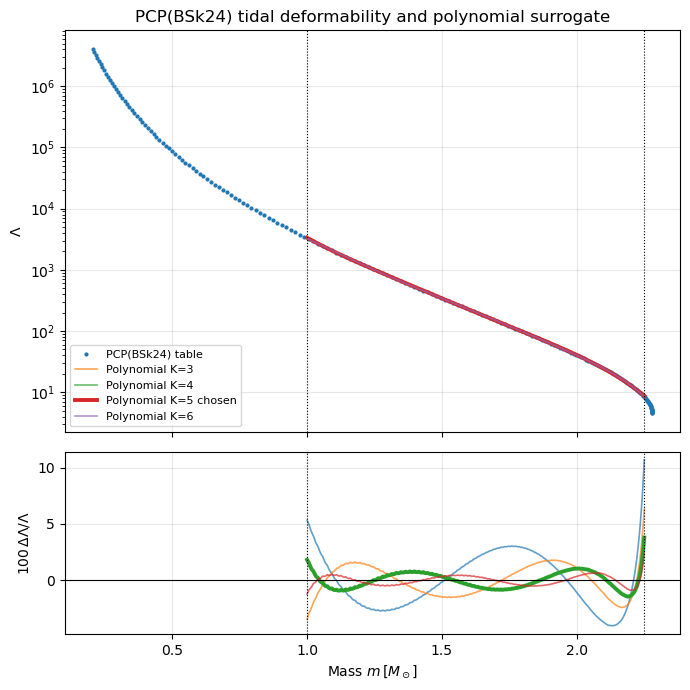

Saved figure to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/bsk24_loglambda_polynomial_fit.png


In [17]:
m_grid = np.linspace(fit_min, fit_max, 500)
lambda_grid_table = np.interp(m_grid, mass, lambda_tidal)

fig, axes = plt.subplots(
    2, 1,
    figsize=(7.0, 7.0),
    sharex=True,
    gridspec_kw={'height_ratios': [2.2, 1.0]}
)

ax = axes[0]
ax.plot(mass, lambda_tidal, '.', ms=4, label='PCP(BSk24) table')

for K in orders:
    coeffs = fits[K]
    lambda_model = np.exp(np.polyval(coeffs, m_grid))
    if K == chosen_order:
        ax.plot(m_grid, lambda_model, lw=2.8, label=f'Polynomial K={K} chosen')
    else:
        ax.plot(m_grid, lambda_model, lw=1.2, alpha=0.7, label=f'Polynomial K={K}')

ax.set_yscale('log')
ax.set_ylabel(r'$\Lambda$')
ax.set_title('PCP(BSk24) tidal deformability and polynomial surrogate')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
for K in orders:
    coeffs = fits[K]
    lambda_model = np.exp(np.polyval(coeffs, m_grid))
    residual_percent = 100.0 * (lambda_model - lambda_grid_table) / lambda_grid_table
    if K == chosen_order:
        ax.plot(m_grid, residual_percent, lw=2.8, label=f'K={K} chosen')
    else:
        ax.plot(m_grid, residual_percent, lw=1.2, alpha=0.7, label=f'K={K}')

ax.axhline(0.0, color='black', lw=0.8)
ax.set_xlabel(r'Mass $m\,[M_\odot]$')
ax.set_ylabel(r'$100\,\Delta\Lambda/\Lambda$')
ax.grid(alpha=0.3)

for ax_i in axes:
    ax_i.axvline(fit_min, color='black', lw=0.8, ls=':')
    ax_i.axvline(fit_max, color='black', lw=0.8, ls=':')

fig.tight_layout()
figure_path = figures_dir / 'bsk24_loglambda_polynomial_fit.png'
fig.savefig(figure_path, dpi=200)
plt.show()

print(f'Saved figure to {figure_path}')


## Save polynomial coefficients


In [18]:
output_path = processed_dir / 'bsk24_loglambda_polyfit.npz'

save_dict = {
    'fit_min': fit_min,
    'fit_max': fit_max,
    'orders': np.array(orders),
    'chosen_order': chosen_order,
    'chosen_coeffs': fits[chosen_order],
    'metrics': np.array(metrics),
}

for K in orders:
    save_dict[f'coeffs_K{K}'] = fits[K]

np.savez(output_path, **save_dict)
print(f'Saved polynomial fit to {output_path}')


Saved polynomial fit to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/data/processed/bsk24_loglambda_polyfit.npz
